In [1]:
from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

The following examples introduce file operations and signal generators commonly used in DSP with Python.
Import these modules before running any of the code snippets below: 


In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt


-----

# Implementing Basic Signals

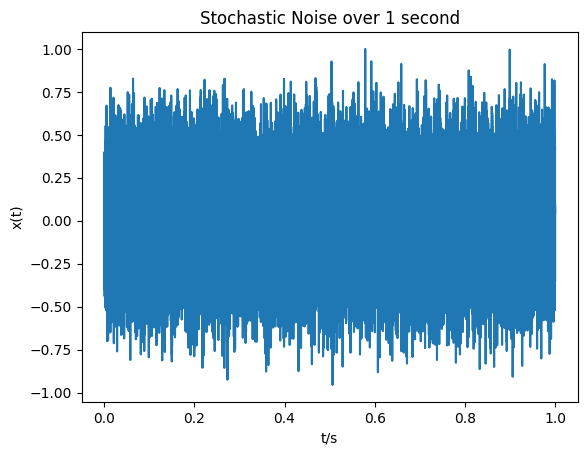

In [3]:
#White Noise with numpy

whiteNoise = np.random.normal(loc=0.0, scale=1.0, size=48000)

#Normalize to the peak amplitude of the signal
peakAmplitude = np.max(np.abs(whiteNoise))
whiteNoise = whiteNoise/peakAmplitude

#A Time Axis
timeAxis = np.linspace(0,1,48000)

plt.plot(timeAxis, whiteNoise)
plt.xlabel("t/s")
plt.ylabel("x(t)")
plt.title("Stochastic Noise over 1 second")
plt.show()


# Generate A Sine Wave, Periodic Signal

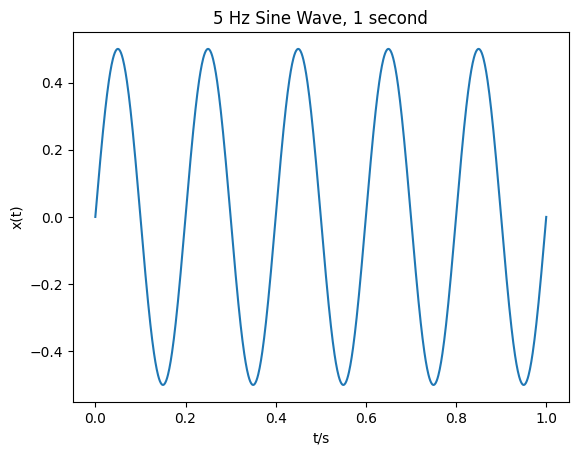

In [5]:
samplerate = 1000  # 1000 points every second
# 1 second of audio
timeAxis  = np.linspace(0, 1, samplerate)
freq = 5
sineWave = 0.5*np.sin(2*np.pi*freq*timeAxis)

plt.plot(timeAxis, sineWave)
plt.xlabel("t/s")
plt.ylabel("x(t)")
plt.title("5 Hz Sine Wave, 1 second")
plt.show()

-----

# Probability Mass Function

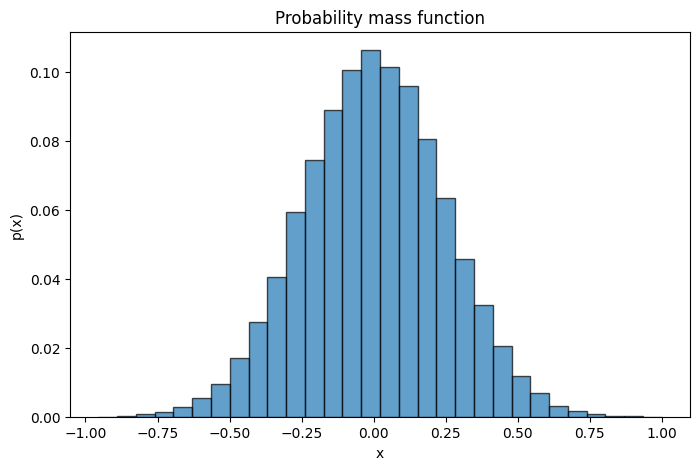

Sum of PMF values = 1.0


In [7]:

# We use numpy histogram to get the relative count
# values resulting from the given random distribution

count, bin_edges = np.histogram(whiteNoise, bins=30, density=False)

# The count array is then converted to probabilities
pmf = count / np.sum(count)

# Making things a little neater in the plot by computing bin centers (Best Practice!)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Plot
plt.figure(figsize=(8,5))

# Review the matplotlib.plt.bar documentation

plt.bar(bin_centers, pmf ,width=(bin_edges[1] - bin_edges[0]), alpha=0.7, edgecolor='k')
plt.title('Probability mass function')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.show()

# Check that the PMF sums to 1
print("Sum of PMF values =", np.sum(pmf))


------

# Implementing Basic Sequences

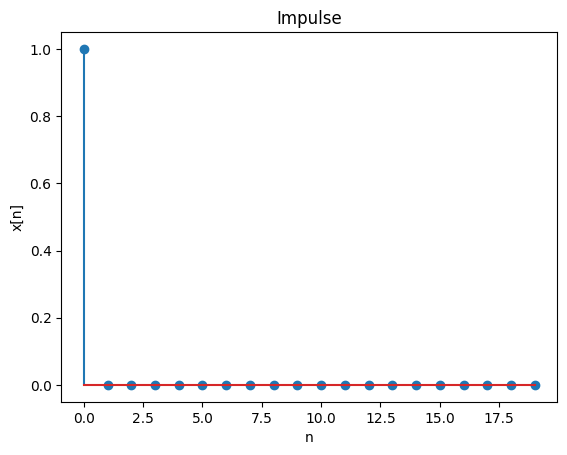

In [8]:
# Impulse

impulse = np.zeros(20)
impulse[0] = 1

plt.stem(impulse)
plt.xlabel("n")
plt.ylabel("x[n]")
plt.title("Impulse")
plt.show()

#note: Self practice: Try shifting the impulse and experimenting with 
#      the properties of an impulse signal


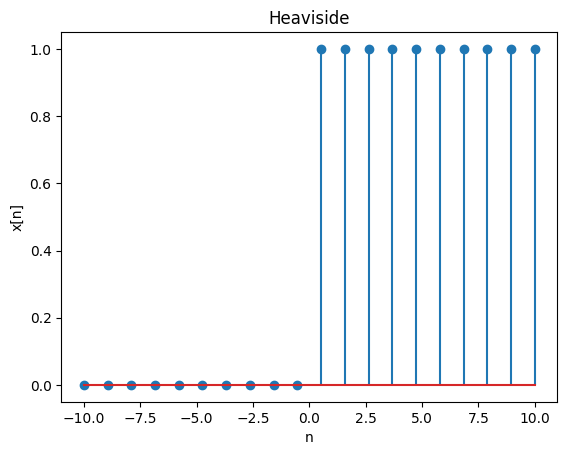

In [9]:
#Heaviside Step Function
# Generate the step values
step_axis = np.linspace(-10, 10, 20)
step = np.where(step_axis >= 0, 1, 0)
plt.stem(step_axis,step)
plt.xlabel("n")
plt.ylabel("x[n]")
plt.title("Heaviside")
plt.show()

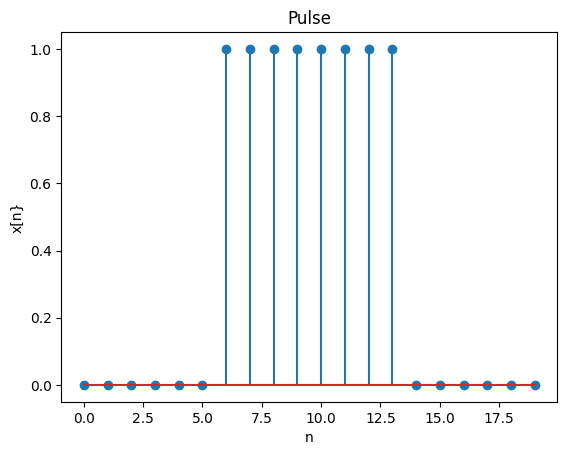

In [10]:
# Pulse

step = np.zeros(20)
step[6:14] = 1

plt.stem(step)
plt.xlabel("n")
plt.ylabel("x[n}")
plt.title("Pulse")
plt.show()


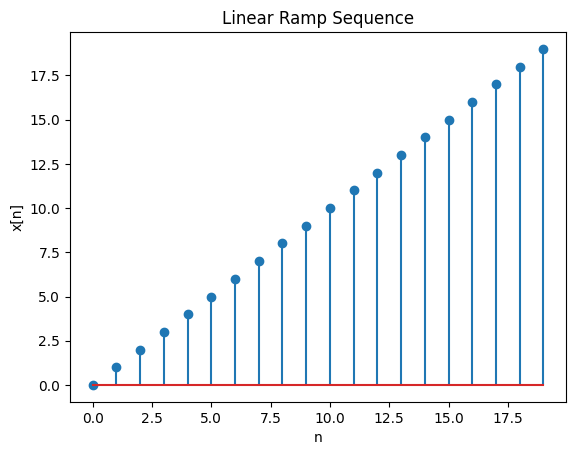

In [11]:
# Linear Ramp

linearRamp = np.arange(0,20)


plt.stem(linearRamp)
plt.xlabel("n")
plt.ylabel("x[n]")
plt.title("Linear Ramp Sequence")
plt.show()

#note: Self practice -> How would you make this exponential??
# Can this work with linspace?

------

# Common Signal Operations


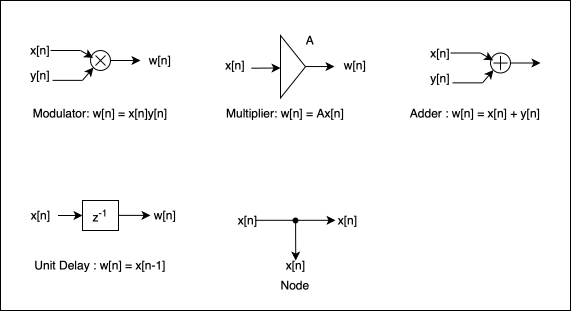

In [1]:
# embedding an image like this allows relative paths with nb-convert
# make sure to hide the cell when converting (in metadata)

from IPython import display 
display.display(display.SVG(filename="../graphics/operations.svg"))


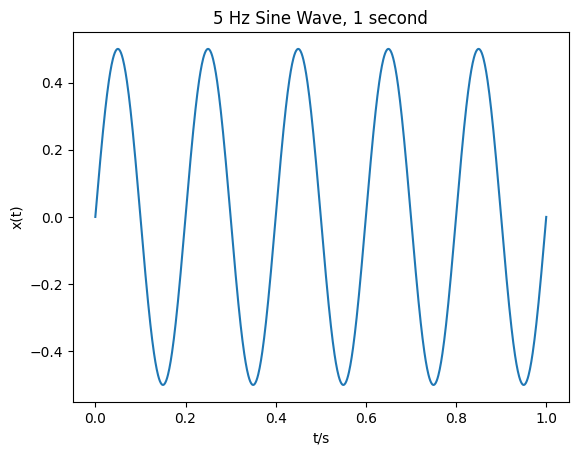

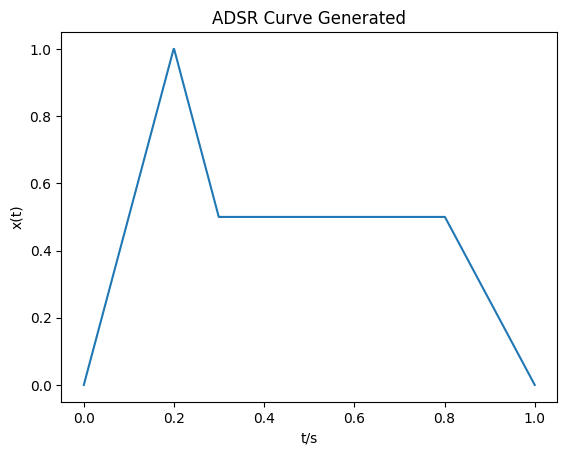

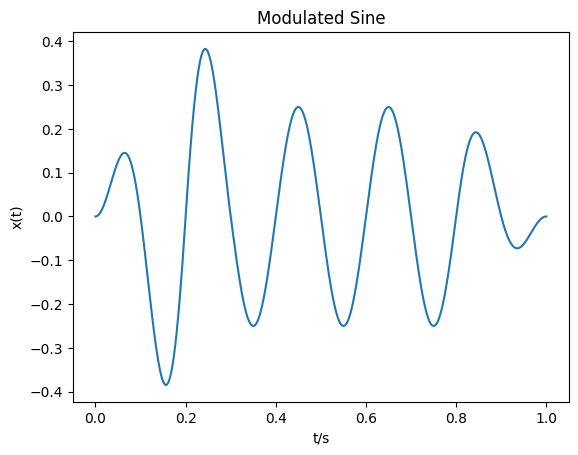

In [13]:
# Implement ADSR On The Previously Generated Sine


samplerate = 1000 # 1000 points every second
# 1 second of audio
timeAxis  = np.linspace(0, 1, samplerate)
freq = 5
sineWave = 0.5*np.sin(2*np.pi*freq*timeAxis)

plt.plot(timeAxis, sineWave)
plt.xlabel("t/s")
plt.ylabel("x(t)")
plt.title("5 Hz Sine Wave, 1 second")
plt.show()

#Assume sustain level is 50%

def ADSR(attackTime, decayTime, sustainTime, releaseTime, samplerate):
    
    # An attack is a linear ramp up
    attack = np.linspace(0,1,int(samplerate*attackTime))
    # An Decay is a linear ramp down
    decay = np.linspace(1,0.5,int(samplerate*decayTime))
    #Sustain is a unit-step function
    sustain = np.linspace(0.5,0.5,int(samplerate*sustainTime))
    # Release is another linear ramp down
    release = np.linspace(0.5,0,int(samplerate*releaseTime))
    
    adsr = np.concatenate((attack,decay, sustain, release), axis=None)
    return adsr

# Parameters in seconds
attackTime = 0.2
decayTime = 0.1
sustainTime = 0.5
releaseTime = 0.2

#Calling the function
adsr = ADSR(attackTime, decayTime, sustainTime, releaseTime, samplerate)

plt.figure()
plt.plot(timeAxis,adsr)
plt.xlabel("t/s")
plt.ylabel("x(t)")
plt.title("ADSR Curve Generated")
plt.show()


w = sineWave*adsr


plt.figure()
plt.plot(timeAxis,w)
plt.xlabel("t/s")
plt.ylabel("x(t)")
plt.title("Modulated Sine")
plt.show()


------

# Activity: Apply an ADSR Envelope

1. Create your own ADSR envelope and modulate an audiorate sineWave to avoid the clicks during playback, experiment with the different parameters.

2. Write into a wavfile